In [1]:
### DEFINING CONFIGS AND IMPORTING LIBRARIES ###

import torch
import numpy as np
import os
import time, psutil

def log(message, priority=0, indent=0):
    current_time = time.strftime("%H:%M:%S")
    gpu_memory_reserved = torch.cuda.memory_reserved() / 1024**3 if torch.cuda.is_available() else 0
    process = psutil.Process()
    ram_usage = process.memory_info().rss / 1024**3
    print(f"[{current_time} gpu {gpu_memory_reserved:.1f}G ram {ram_usage:.1f}G] {' '*4*indent}{message}")

subject_id = 1
session_id = 2
subject_identifier = f'mgh{subject_id}'
batch_size = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

log(f"Loading subjects...", priority=0)
from mgh2024_subject import MGH2024Subject
subject = MGH2024Subject(subject_id, dtype=torch.float32, cache=False, allow_corrupted=False)
all_subjects = {subject.subject_identifier: subject}

log(f"Loading the seizure dataset...", priority=0)
# WINDOW SIZE (seconds): window size that defines how much neural data to give at once
# SEIZURE REGION SIZE (seconds): for the seizure windows, how close to a "seizure" annotation does the data point have to be?
# ANNOTATION_PADDING=60*10 (seconds): for the non-seizure windows, how far every does the data point have to be from any annotation?
from mgh2024_seizure_dataset import MGHSeizureDataset
dataset = MGHSeizureDataset(subject, session_id, WINDOW_SIZE=1, SEIZURE_REGION_SIZE=10)
log(f"Total number of samples: {len(dataset)}", indent=1)
log(f"Sample shape: {dataset[0][0].shape}, Sample label: {dataset[0][1]}", indent=1)
# Sample shape = (n_electrodes, window_size * sample_rate)

[13:37:08 gpu 0.0G ram 0.4G] Loading subjects...
[13:37:10 gpu 0.0G ram 0.5G] Loading the seizure dataset...
[13:37:10 gpu 0.0G ram 0.5G]     Total number of samples: 148
[13:37:11 gpu 0.0G ram 0.5G]     Sample shape: torch.Size([246, 1024]), Sample label: 0


In [2]:
### LOAD THE DATASET AND RUN THROUGH THE MODEL ###

# 1. Loading the data onto the GPU
batch_input = []
batch_label = []
n_skip_over_items = 1 # has to be odd so that both 1 and 0 labels are represented
for i in range(0, len(dataset), n_skip_over_items):
    batch_input.append(dataset[i][0].unsqueeze(0))
    batch_label.append(dataset[i][1])

batch_input = torch.cat(batch_input, dim=0).to(device, dtype=torch.float32) # shape (batch_size, n_electrodes, n_samples)
batch_label = torch.tensor(batch_label) # shape (batch_size)

original_batch = {
    'data': batch_input,
    'electrode_labels': [subject.electrode_labels],
    'metadata': {
        'subject_identifier': subject_identifier,
        'sampling_rate': subject.get_sampling_rate(session_id)
    }
}

In [16]:
### LOAD MODEL ###

randomly_initialized_model = True

log(f"Loading model (randomly initialized: {randomly_initialized_model})...", priority=0)
import models
import torch
from omegaconf import OmegaConf
def build_model(cfg):
    ckpt_path = cfg.upstream_ckpt
    init_state = torch.load(ckpt_path, weights_only=False)
    upstream_cfg = init_state["model_cfg"]
    upstream = models.build_model(upstream_cfg)
    return upstream
def load_model_weights(model, states, multi_gpu):
    if multi_gpu:
        model.module.load_weights(states)
    else:
        model.load_weights(states)
log(f"Loading the model...", priority=0)
ckpt_path = "pretrained_weights/stft_large_pretrained.pth"
cfg = OmegaConf.create({"upstream_ckpt": ckpt_path})
model = build_model(cfg)
model.to('cuda')
init_state = torch.load(ckpt_path, weights_only=False)
if not randomly_initialized_model:
    load_model_weights(model, init_state['model'], False)
del init_state
torch.cuda.empty_cache()     # optional: releases unused GPU cached blocks back to the OS

log(f"Loading complete!", priority=0)

[15:32:23 gpu 3.3G ram 1.5G] Loading model (randomly initialized: True)...
[15:32:23 gpu 3.3G ram 1.5G] Loading the model...


/net/vast-storage/scratch/vast/yanglab/zaho/BrainBERT/.venv/lib/python3.9/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[15:32:25 gpu 1.8G ram 2.0G] Loading complete!


In [17]:

### SETUP FEATURE GENERATION FUNCTION ###

from scipy import signal, stats
import numpy as np
import gc
def get_stft(x, fs, clip_fs=-1, normalizing=None, boundary=None, clip=0, **kwargs):
    assert len(x.shape) == 3, "x must be of shape (batch_size, n_channels, n_samples)"

    # x is of shape (batch_size, n_channels, n_samples)
    f, t, Zxx = signal.stft(x, fs, boundary=boundary, **kwargs)
    # Zxx is of shape (batch_size, n_channels, n_freqs, n_times)
   
    Zxx = Zxx[:, :, :clip_fs]
    f = f[:clip_fs]

    Zxx = np.abs(Zxx)
    if normalizing=="zscore":
        if clip > 0: Zxx = Zxx[:, :, :, clip:-clip]
        Zxx = stats.zscore(Zxx, axis=-1)
        t = t[clip:-clip]
    elif normalizing=="db":
        if clip > 0: Zxx = Zxx[:, :, :, clip:-clip]
        Zxx = np.log2(Zxx)
        t = t[clip:-clip]

    if np.isnan(Zxx).any():
        import pdb; pdb.set_trace()

    return f, t, Zxx # shape: (batch_size, n_channels, n_freqs, n_times)

def get_brainbert_features(x, fs=2048, verbose=False):
    """
    x: np.ndarray of shape (batch_size, n_channels, n_samples)
    returns: Torch Tensor of shape (batch_size, n_channels, n_timebins, d_model)
    """
    assert len(x.shape) == 3, "x must be of shape (batch_size, n_channels, n_samples)"
    n_channels = x.shape[1]

    with torch.no_grad():
        log(f"Getting STFT...", priority=4, indent=3)
        # slice this batch
        # STFT -> (batch_i, n_channels, n_freqs, n_times)
        f, t, linear = get_stft(
            x, fs, clip_fs=40,
            nperseg=400, noverlap=350,
            normalizing="zscore", return_onesided=True
        )
        batch_i, n_channels, n_freqs, n_times = linear.shape
        
        # to tensor shape: (batch_i * n_channels, n_times, n_freqs)
        batch_inputs = torch.FloatTensor(linear).transpose(-1, -2).to('cuda')
        batch_inputs = batch_inputs.reshape(batch_i * n_channels, n_times, n_freqs)

        batch_mask = torch.zeros(batch_inputs.shape[:2], dtype=torch.bool, device='cuda')

        # model forward -> (batch_i*n_channels, n_times, d_model)
        batch_out = model.forward(batch_inputs, batch_mask, intermediate_rep=True)
        
        d_model = batch_out.shape[-1]
        batch_out = batch_out.reshape(batch_i, n_channels, n_times, d_model)
        
        # Make a copy to ensure no references to GPU memory persist
        result = batch_out.clone()
        if verbose:
            log(f"Forwarding batch...", priority=4, indent=3)

    # Clean up intermediate variables immediately
    del batch_inputs, batch_mask, linear, f, t, batch_out
    torch.cuda.empty_cache()
    gc.collect()
    
    return result

In [18]:
batch = { # make a copy of the original batch
    'data': original_batch['data'].clone(), # shape (batch_size, n_electrodes, n_samples)
    'electrode_labels': original_batch['electrode_labels'],
    'metadata': original_batch['metadata']
}

# electrode_subset = ['LHH13', 'LAMY1', 'LHT11', 'LFId2', 'LFIb5', 'LTSb2', 'LHH10', 'LFIc9']
electrode_subset = sorted(subject.electrode_labels)
electrode_indices = [subject.electrode_labels.index(electrode) for electrode in electrode_subset]
batch['data'] = batch['data'][:, electrode_indices]
batch['electrode_labels'] = [electrode_subset]
#batch_label = batch_label.unsqueeze(1).repeat(1, len(electrode_indices))
log(f"Batch shape: {batch['data'].shape}")
log(f"Batch label shape: {batch_label.shape}")

log(f"Forwarding through the model...", priority=0)
from laplacian_rereferencing import laplacian_rereference_batch
batch = laplacian_rereference_batch(batch, inplace=True)

features = get_brainbert_features(batch['data'].cpu().numpy(), verbose=True) 
features = features.mean(dim=2) # shape (batch_size, n_electrodes, d_model)

log(f"Features shape: {features.shape}") # (batch_size, n_electrodes, d_model)

[15:32:25 gpu 1.8G ram 2.0G] Batch shape: torch.Size([148, 246, 1024])
[15:32:25 gpu 1.8G ram 2.0G] Batch label shape: torch.Size([148])
[15:32:25 gpu 1.8G ram 2.0G] Forwarding through the model...
[15:32:25 gpu 1.8G ram 2.0G]             Getting STFT...
[15:32:29 gpu 28.1G ram 2.0G]             Forwarding batch...
[15:32:33 gpu 3.3G ram 1.9G] Features shape: torch.Size([148, 246, 768])


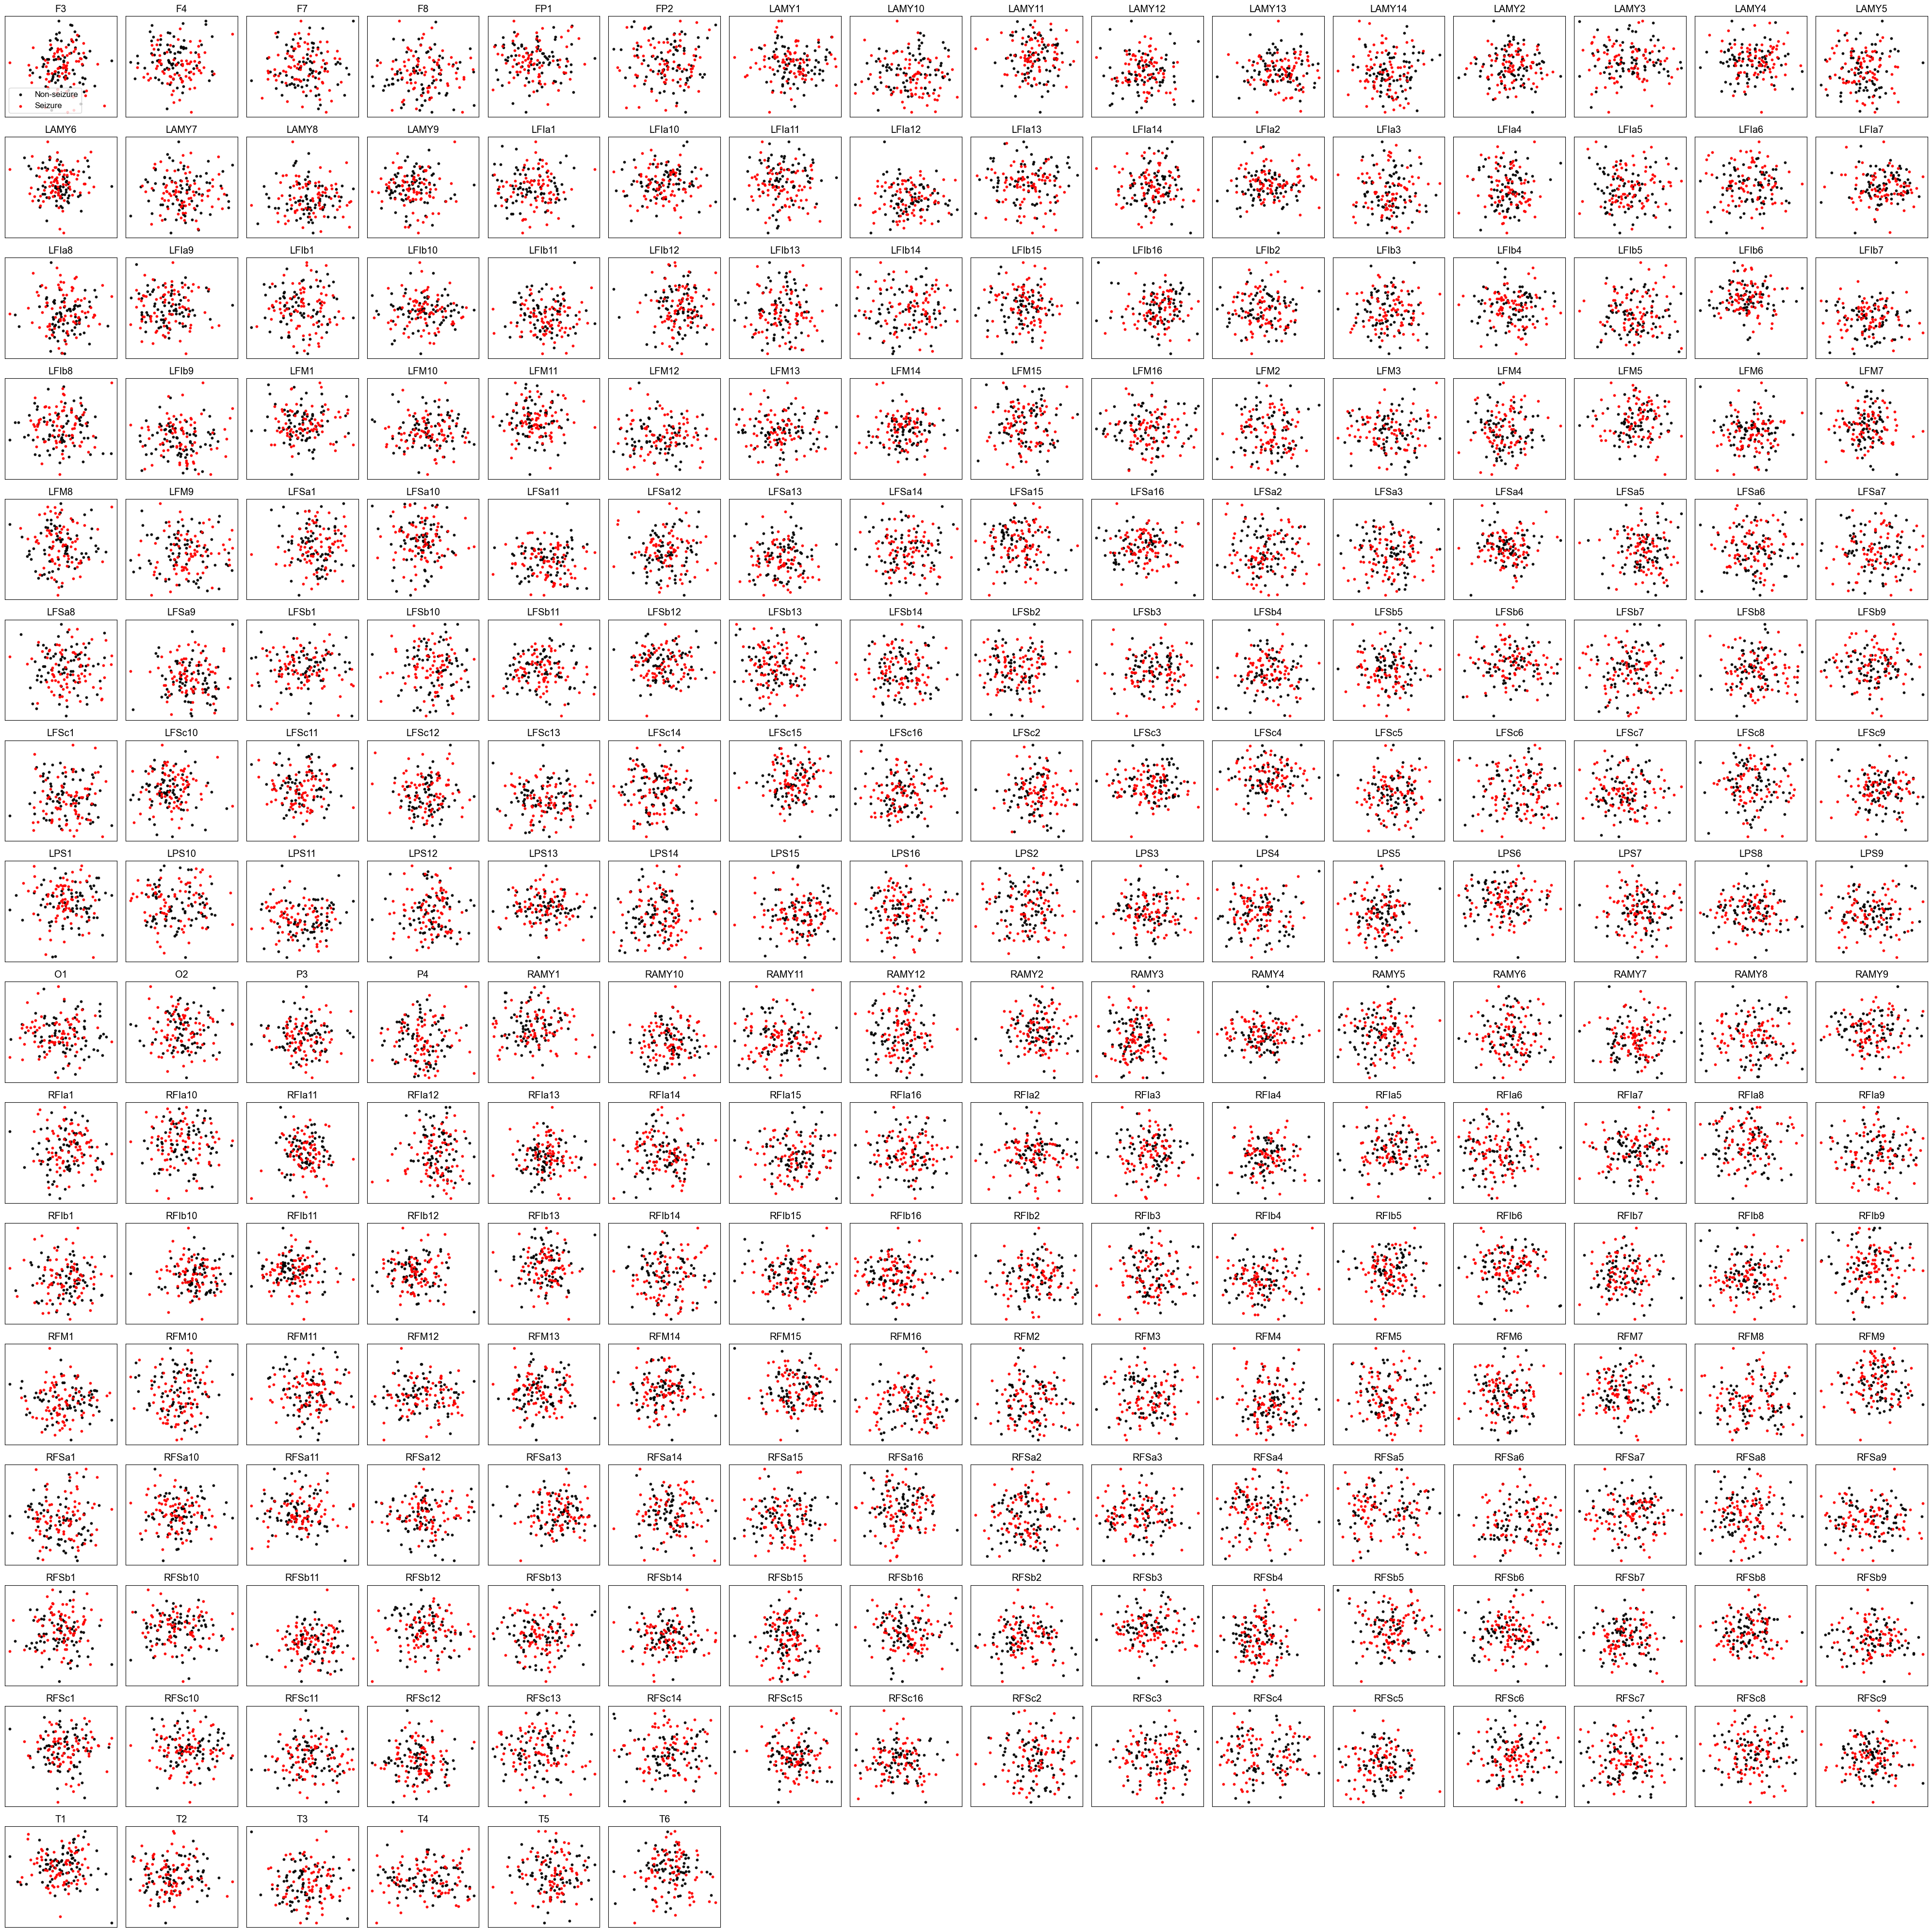

In [19]:
### PCA PLOT ###

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pca(features, save_path=None, electrode_label_subset=None):

    # Calculate number of rows/cols needed for roughly square grid
    n_electrodes = features.shape[1]
    grid_size = int(np.ceil(np.sqrt(n_electrodes)))

    # Create subplot grid
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('font_arial.ttf')
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['font.size'] = 12
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(grid_size//4*10,grid_size//4*10))
    axes = axes.flatten()

    electrode_is = range(n_electrodes)
    if electrode_label_subset is not None:
        electrode_is = [i for i in electrode_is if subject.electrode_labels[electrode_indices[i]] in electrode_label_subset]

    # For each electrode
    for electrode_i in range(n_electrodes):
        # Get features for this electrode
        electrode_features = features[:, electrode_i, :]  # shape: (batch_size, d_model)
        electrode_labels = batch_label#[:, electrode_i]    # shape: (batch_size)
        
        # Fit and transform PCA
        pca = PCA(n_components=2)
        features_2d = pca.fit_transform(electrode_features.cpu().float().detach().numpy())
        
        # Plot points colored by label
        for label in [0, 1]:
            mask = electrode_labels.cpu() == label
            color = 'black' if label == 0 else 'red'
            label_str = 'Seizure' if label == 1 else 'Non-seizure'
            axes[electrode_i].scatter(features_2d[mask, 0], features_2d[mask, 1],
                                    c=color, label=label_str, alpha=0.9, s=10)
        
        electrode_label = subject.electrode_labels[electrode_indices[electrode_i]]
        axes[electrode_i].set_title(f'{electrode_label}')
        # axes[electrode_i].set_xlabel('PC1')
        # axes[electrode_i].set_ylabel('PC2')
        axes[electrode_i].set_xticks([])
        axes[electrode_i].set_yticks([])

        if electrode_i == 0:
            axes[electrode_i].legend()

    # Hide empty subplots
    for i in range(n_electrodes, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    else:
        plt.show()

plot_pca(features, save_path=f'pca_brainbert{"_randominit" if randomly_initialized_model else ""}.pdf')

Running the same analysis as above but for the raw voltage inputs instead of BrainBERT

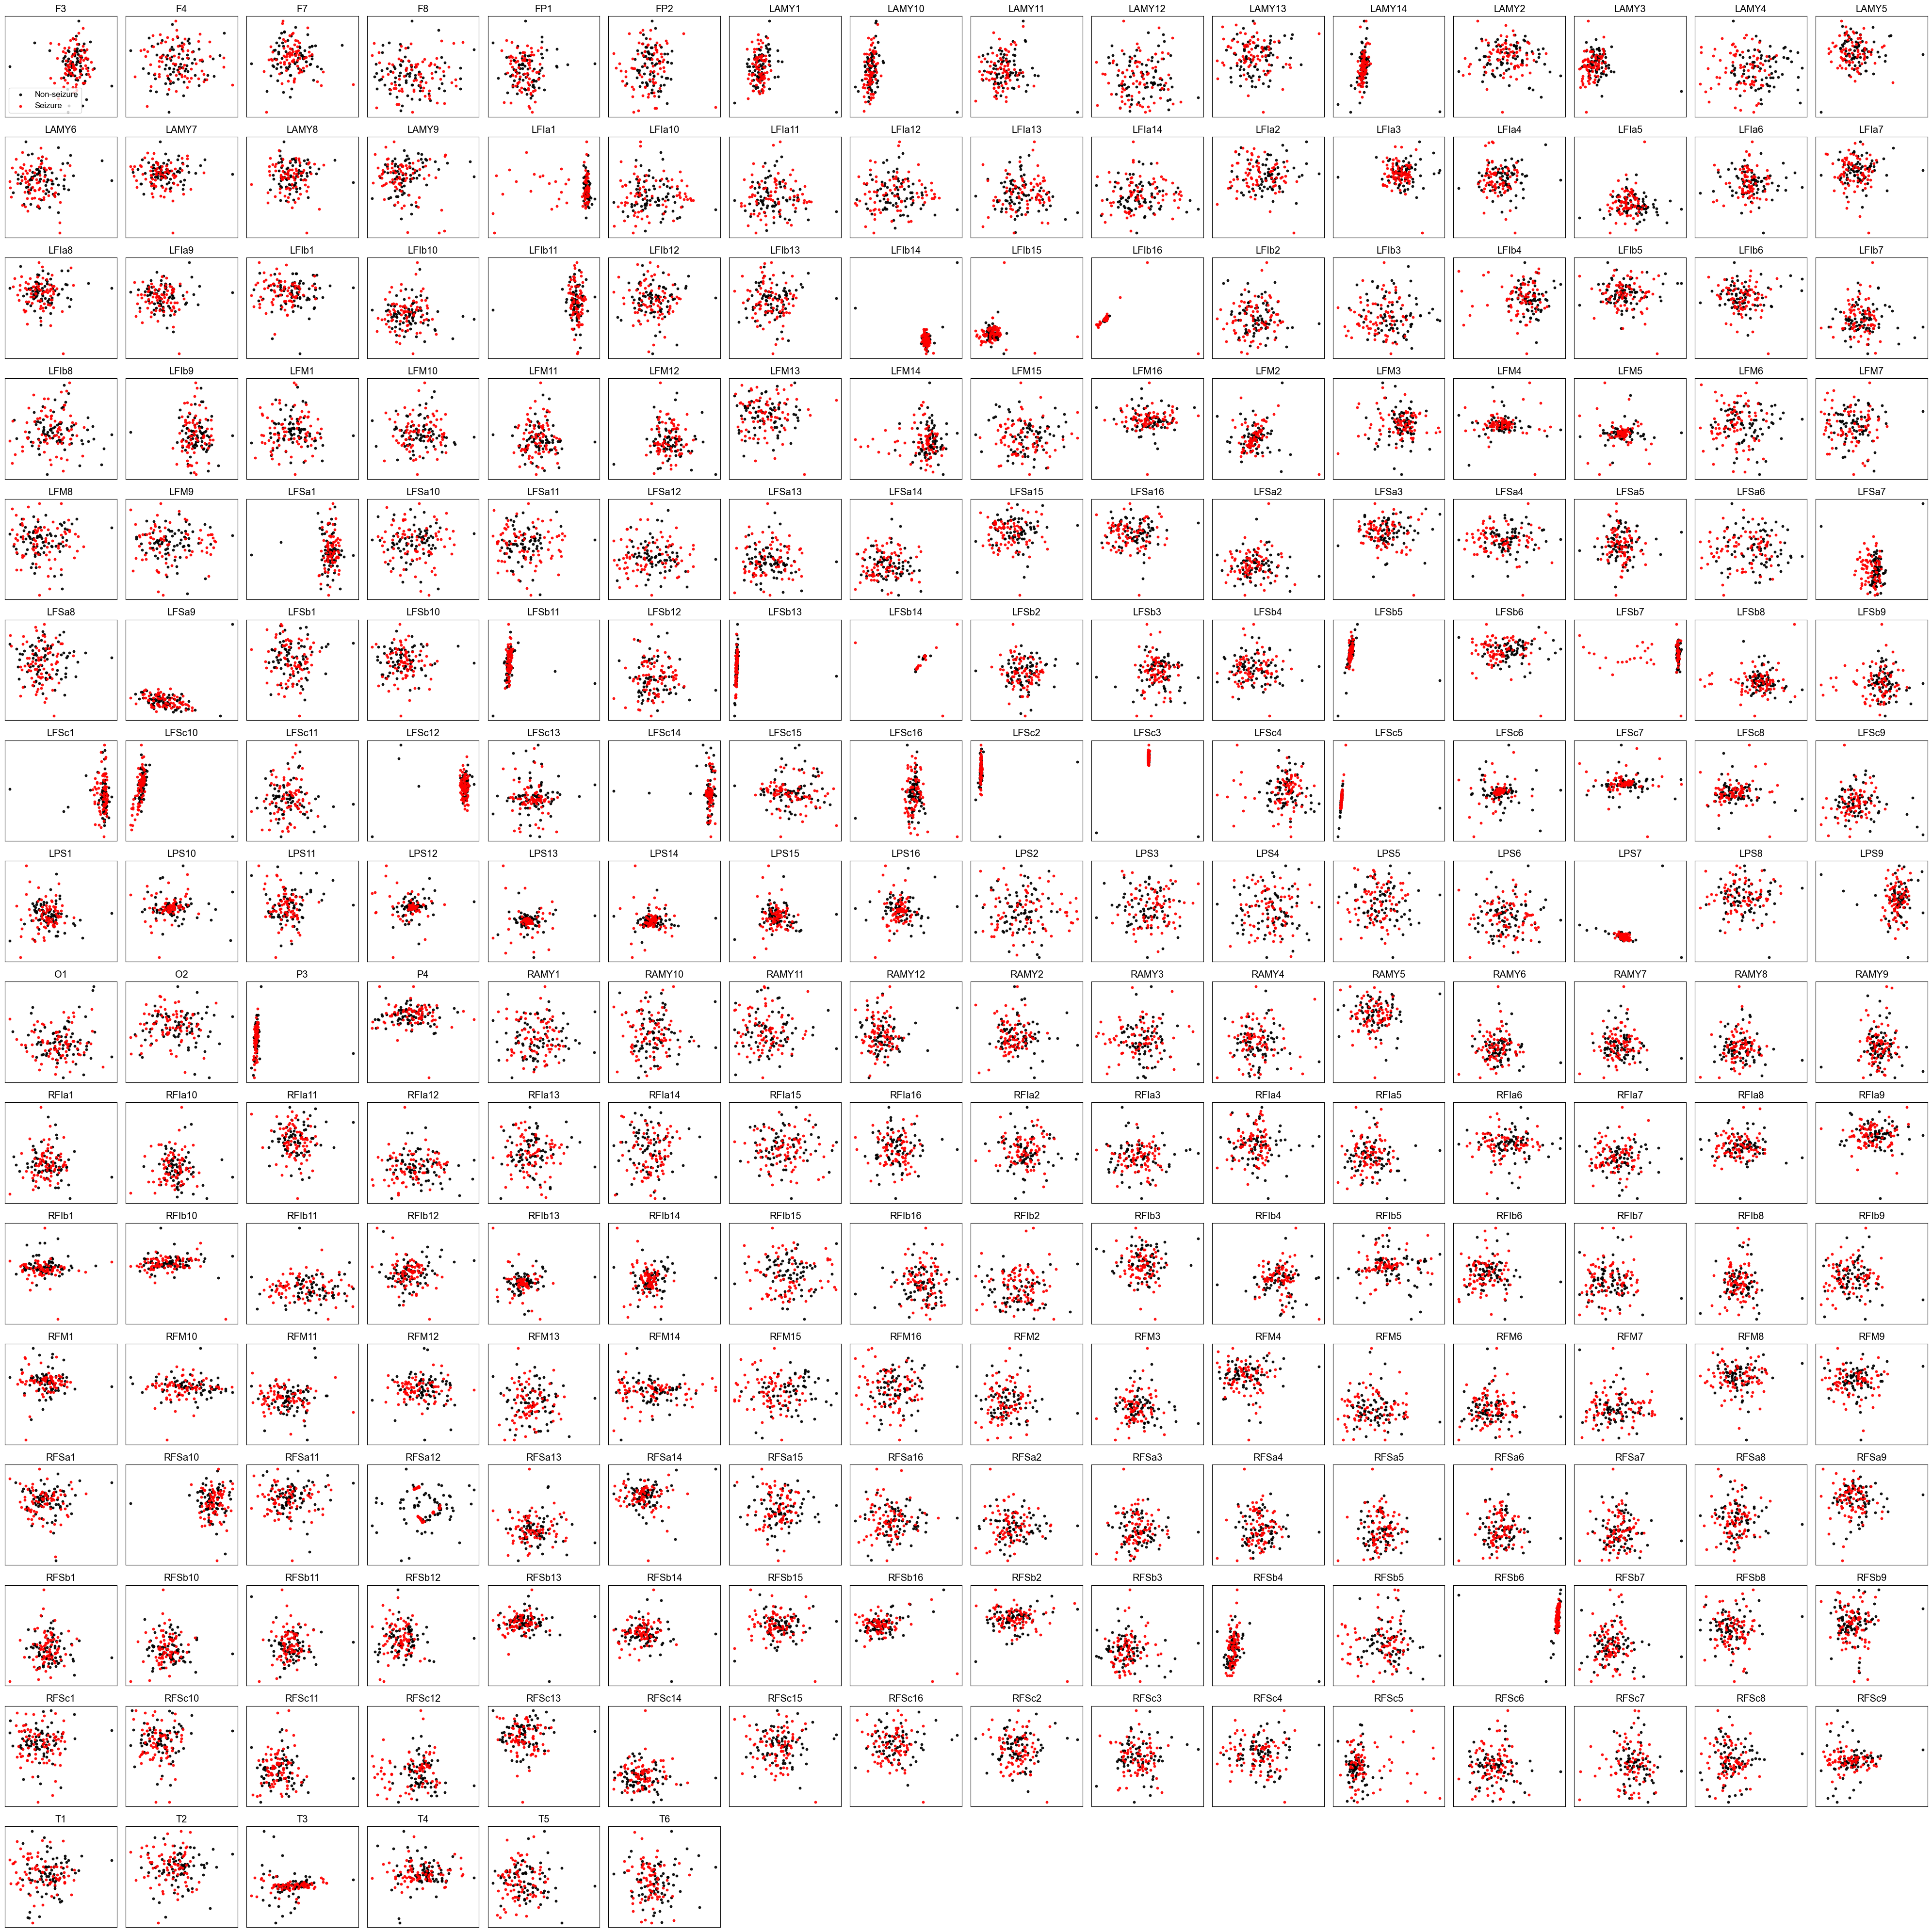

In [15]:
features = original_batch['data'] # shape (batch_size, n_electrodes, n_samples)
plot_pca(features, save_path=f'pca_raw_voltage.pdf')